# Exploration de MNIST depuis MongoDB

Ce notebook répond aux questions d'exploration du sujet. Il lit les collections `mnist_train` et `mnist_test` dans MongoDB, jamais les CSV sources. Les résultats sont exécutés dans Docker après l'import validé.

In [1]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from pymongo import MongoClient

MONGODB_URI = os.environ.get('MONGODB_URI', 'mongodb://mongo:27017')
MONGODB_DATABASE = os.environ.get('MONGODB_DATABASE', 'postal_ocr')
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
db = client[MONGODB_DATABASE]
client.admin.command('ping')
print(f'Base connectée : {MONGODB_DATABASE}')

Base connectée : postal_ocr


In [2]:
def load_collection(name):
    rows = list(db[name].find({}, {'label': 1, 'pixels': 1, 'source_index': 1}).sort('source_index', 1))
    labels = np.array([row['label'] for row in rows], dtype=np.uint8)
    images = np.stack([np.frombuffer(row['pixels'], dtype=np.uint8).reshape(28, 28) for row in rows])
    return images, labels

train_images, train_labels = load_collection('mnist_train')
test_images, test_labels = load_collection('mnist_test')
assert train_images.shape == (60_000, 28, 28)
assert test_images.shape == (10_000, 28, 28)
print('Train :', train_images.shape, Counter(train_labels))
print('Test  :', test_images.shape, Counter(test_labels))

Train : (60000, 28, 28) Counter({np.uint8(1): 6742, np.uint8(7): 6265, np.uint8(3): 6131, np.uint8(2): 5958, np.uint8(9): 5949, np.uint8(0): 5923, np.uint8(6): 5918, np.uint8(8): 5851, np.uint8(4): 5842, np.uint8(5): 5421})
Test  : (10000, 28, 28) Counter({np.uint8(1): 1135, np.uint8(2): 1032, np.uint8(7): 1028, np.uint8(3): 1010, np.uint8(9): 1009, np.uint8(4): 982, np.uint8(0): 980, np.uint8(8): 974, np.uint8(6): 958, np.uint8(5): 892})


## 1a. Une image du train et son label

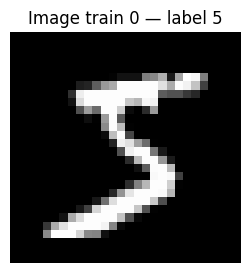

In [3]:
sample_index = 0
plt.figure(figsize=(3, 3))
plt.imshow(train_images[sample_index], cmap='gray')
plt.title(f'Image train {sample_index} — label {train_labels[sample_index]}')
plt.axis('off');
plt.show()

## 1b. Un exemple des chiffres 0 à 9

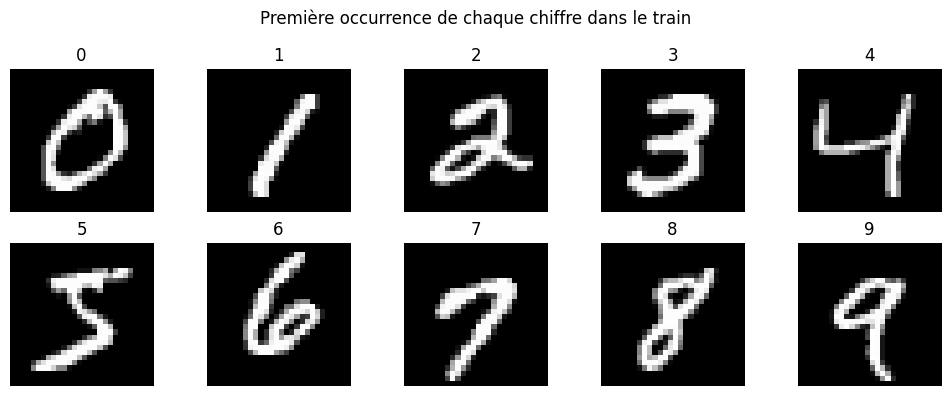

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, axis in enumerate(axes.flat):
    index = np.flatnonzero(train_labels == digit)[0]
    axis.imshow(train_images[index], cmap='gray')
    axis.set_title(str(digit))
    axis.axis('off')
fig.suptitle('Première occurrence de chaque chiffre dans le train')
plt.tight_layout()
plt.show()

## 1c. Les neuf premières écritures du chiffre 7

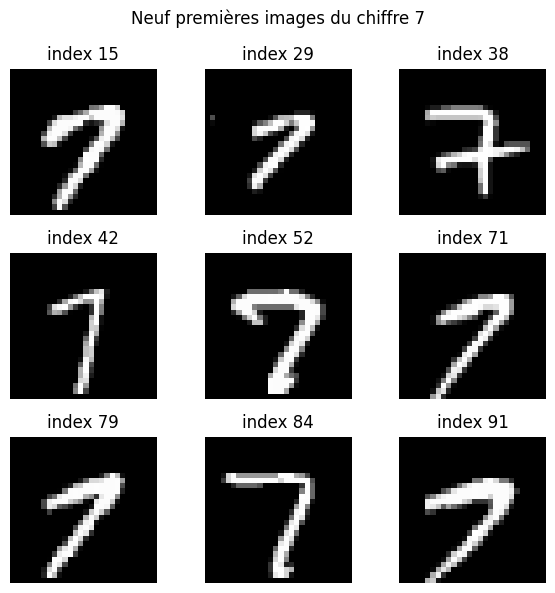

In [5]:
seven_indexes = np.flatnonzero(train_labels == 7)[:9]
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for axis, index in zip(axes.flat, seven_indexes):
    axis.imshow(train_images[index], cmap='gray')
    axis.set_title(f'index {index}')
    axis.axis('off')
fig.suptitle('Neuf premières images du chiffre 7')
plt.tight_layout()
plt.show()

## 1d. Représentant moyen de chaque chiffre

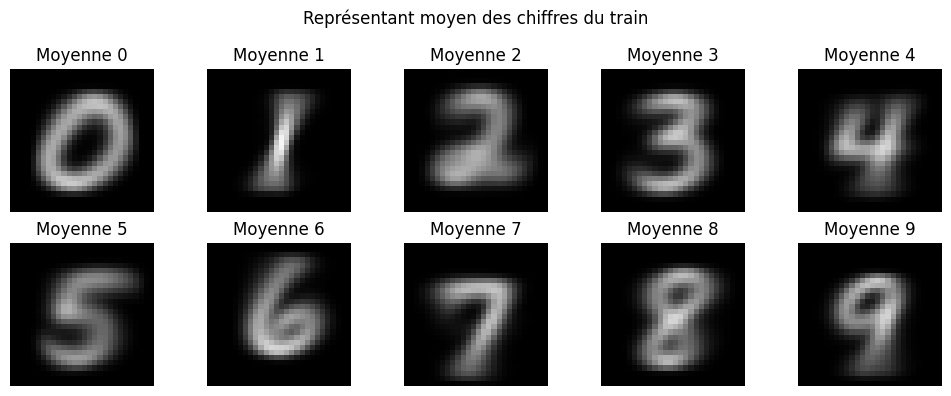

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, axis in enumerate(axes.flat):
    mean_image = train_images[train_labels == digit].mean(axis=0)
    axis.imshow(mean_image, cmap='gray', vmin=0, vmax=255)
    axis.set_title(f'Moyenne {digit}')
    axis.axis('off')
fig.suptitle('Représentant moyen des chiffres du train')
plt.tight_layout()
plt.show()

client.close()